In [1]:
from keras_facenet import FaceNet
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from sklearn.metrics.pairwise import cosine_similarity

data_base_path = 'data/images/'

# Load models
embedder = FaceNet()
detector = MTCNN()

def load_and_detect_face(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = detector.detect_faces(image_rgb)[0]
    x, y, width, height = result['box']
    x, y = max(0, x), max(0, y)
    face = image_rgb[y:y+height, x:x+width]
    face = cv2.resize(face, (160, 200))
    plt.imshow(face)
    return face

def get_face_embedding(image_path):
    face_rgb = load_and_detect_face(image_path)
    embedding = embedder.embeddings([face_rgb])[0]
    return embedding

In [20]:
# Process video and get average embedding
video_path = 'data/images/IMG_7109.mp4'
cap = cv2.VideoCapture(video_path)

embeddings = []
frame_count = 0
skip_frames = 5

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % skip_frames == 0:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_faces(rgb_frame)

        for result in results:
            x, y, w, h = result['box']
            x, y = max(0, x), max(0, y)
            face = rgb_frame[y:y+h, x:x+w]
            face = cv2.resize(face, (160, 200))
            # save face image
            cv2.imwrite(f'data/enrollment/face_{frame_count}.jpg', cv2.cvtColor(face, cv2.COLOR_RGB2BGR))

            try:
                embedding = embedder.embeddings([face])[0]
                embeddings.append(embedding)
            except Exception as e:
                print(f"Error embedding face at frame {frame_count}: {e}")

    frame_count += 1

cap.release()
cv2.destroyAllWindows()

# Compute average embedding
avg_embedding = np.mean(embeddings, axis=0)
print("Average embedding:", avg_embedding)

1/1 [==============================] - 0s 31ms/step
Average embedding: [-3.80831249e-02  1.71892755e-02 -5.10244928e-02 -2.53725722e-02
  3.20511386e-02  3.63911428e-02 -7.45942304e-03 -4.21481505e-02
  6.00147471e-02 -7.50083290e-03  4.23728935e-02  5.15215856e-04
  1.89105365e-02  1.05591929e-02 -2.06447896e-02 -7.02132052e-03
  6.91751465e-02  4.79036532e-02  2.31582802e-02 -1.96770579e-02
 -3.11246514e-03 -4.82393242e-03  7.61806592e-02 -2.10322235e-02
 -1.88750308e-02 -4.24662642e-02  4.27577309e-02  2.22516209e-02
 -1.60772577e-02  2.95944134e-04 -3.75676192e-02  9.20817256e-03
 -2.77858526e-02 -2.22684518e-02 -1.73955932e-02  4.61593084e-03
 -8.52322020e-03  3.00376695e-02 -1.50428275e-02 -1.24937454e-02
 -7.25897625e-02 -2.67062709e-02 -7.99125135e-02  2.87759639e-02
  6.44932985e-02 -3.41727585e-02  3.25023383e-02 -1.32376072e-03
 -2.14149617e-02  2.85676960e-02 -2.05680560e-02 -2.69375797e-02
 -2.77301669e-02  9.23436321e-03  6.74768598e-05  7.10037723e-02
 -1.70768518e-02 -1

In [7]:
# After collecting your enrollment embeddings
enrollment_embeddings = np.array(embeddings)
mean_embedding = np.mean(enrollment_embeddings, axis=0)

# Distances to center
distances = np.linalg.norm(enrollment_embeddings - mean_embedding, axis=1)

# Threshold based on intra-user variation
mean_distance = np.mean(distances)
std_distance = np.std(distances)
threshold = mean_distance + 2 * std_distance  # 2 can be tuned

print(f"Adaptive threshold set at: {threshold:.4f}")

Adaptive threshold set at: 0.7559


1/1 [==============================] - 0s 53ms/step
0.5145543
User authenticated ✅


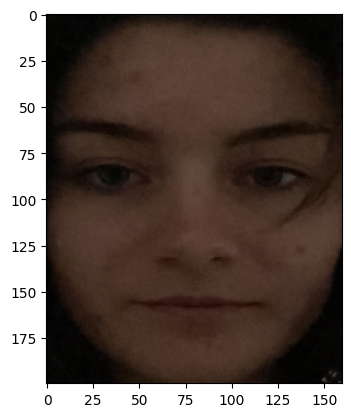

In [18]:
# Later for authentication
embedding_to_test = get_face_embedding(data_base_path + 'Screenshot 2025-04-19 at 16.54.53.png')
distance = np.linalg.norm(embedding_to_test - mean_embedding)

print(distance)
if distance < threshold:
    print("User authenticated ✅")
else:
    print("User revoked ❌")

1/1 [==============================] - 0s 32ms/step
Cosine similarity: 0.8574917


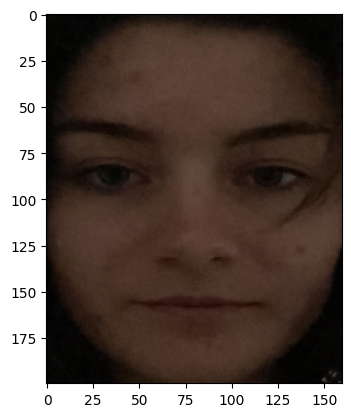

In [19]:
# Compare with input image
embedding1 = get_face_embedding(data_base_path + 'Screenshot 2025-04-19 at 16.54.53.png')
similarity_score = cosine_similarity(avg_embedding.reshape(1, -1), embedding1.reshape(1, -1))[0][0]

print("Cosine similarity:", similarity_score)